In [42]:
# Data handling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Display settings (better readability)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [43]:
# Load datasets
orders = pd.read_csv("sushi_orders.csv")
order_items = pd.read_csv("sushi_order_items.csv")
daily_pnl = pd.read_csv("sushi_daily_pnl.csv")
customers = pd.read_csv("sushi_customers.csv")
reviews = pd.read_csv("sushi_reviews.csv")
staff = pd.read_csv("sushi_staff.csv")

In [44]:
# Check shape (rows, columns)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Daily PnL:", daily_pnl.shape)

# Preview first 5 rows
orders.head()

Orders: (83890, 21)
Order Items: (998920, 7)
Daily PnL: (3653, 15)


,order_id,date,year,month,quarter,day_of_week,is_weekend,is_holiday,customer_id,customer_segment,is_local,channel,party_size,revenue,cogs,gross_profit,discount,tip,delivery_fee,total_collected,rating
0,1,2015-01-01,2015,1,1,Thu,False,True,79,occasional,True,dine_in,2,29.0,9.14,19.86,0.0,5.47,0.0,34.47,NaN
1,2,2015-01-01,2015,1,1,Thu,False,True,50,occasional,True,takeaway,3,86.5,26.92,59.58,0.0,0.00,0.0,86.50,NaN
2,3,2015-01-01,2015,1,1,Thu,False,True,44,one_time,False,dine_in,2,53.5,14.61,38.89,0.0,7.86,0.0,61.36,NaN
3,4,2015-01-01,2015,1,1,Thu,False,True,27,regular,True,takeaway,5,180.5,53.37,127.13,0.0,0.00,0.0,180.50,NaN
4,5,2015-01-01,2015,1,1,Thu,False,True,4,occasional,False,dine_in,4,162.0,52.04,109.96,16.2,42.74,0.0,188.54,NaN


In [45]:
# Check column names
print(orders.columns)

# Check data types and nulls
orders.info()

Index(['order_id', 'date', 'year', 'month', 'quarter', 'day_of_week',
       'is_weekend', 'is_holiday', 'customer_id', 'customer_segment',
       'is_local', 'channel', 'party_size', 'revenue', 'cogs', 'gross_profit',
       'discount', 'tip', 'delivery_fee', 'total_collected', 'rating'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 83890 entries, 0 to 83889
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          83890 non-null  int64  
 1   date              83890 non-null  str    
 2   year              83890 non-null  int64  
 3   month             83890 non-null  int64  
 4   quarter           83890 non-null  int64  
 5   day_of_week       83890 non-null  str    
 6   is_weekend        83890 non-null  bool   
 7   is_holiday        83890 non-null  bool   
 8   customer_id       83890 non-null  int64  
 9   customer_segment  83890 non-null  str    
 10  is_local          83890

In [46]:
# Convert date columns to datetime
orders['date'] = pd.to_datetime(orders['date'])
order_items['date'] = pd.to_datetime(order_items['date'])
daily_pnl['date'] = pd.to_datetime(daily_pnl['date'])
reviews['date'] = pd.to_datetime(reviews['date'])
customers['joined_date'] = pd.to_datetime(customers['joined_date'])

In [47]:
# Check missing values percentage
orders.isnull().mean() * 100

order_id             0.000000
date                 0.000000
year                 0.000000
month                0.000000
quarter              0.000000
day_of_week          0.000000
is_weekend           0.000000
is_holiday           0.000000
customer_id          0.000000
customer_segment     0.000000
is_local             0.000000
channel              0.000000
party_size           0.000000
revenue              0.000000
cogs                 0.000000
gross_profit         0.000000
discount             0.000000
tip                  0.000000
delivery_fee         0.000000
total_collected      0.000000
rating              81.945405
dtype: float64

In [48]:
# Check duplicates
print("Duplicate Orders:", orders.duplicated().sum())
print("Duplicate Items:", order_items.duplicated().sum())

Duplicate Orders: 0
Duplicate Items: 362417


In [49]:
# Check full row duplicates
duplicate_rows = order_items[order_items.duplicated()]
duplicate_rows.head()

,order_id,date,item,category,unit_price,cogs,gross_profit
7,2,2015-01-01,Spicy Tuna Roll,roll,9.0,2.88,6.12
11,2,2015-01-01,California Roll,roll,8.0,2.24,5.76
12,2,2015-01-01,Salmon Nigiri (2pc),nigiri,5.5,2.09,3.41
13,2,2015-01-01,Spicy Tuna Roll,roll,9.0,2.88,6.12
14,2,2015-01-01,California Roll,roll,8.0,2.24,5.76


In [50]:
# Count items per order
order_items.groupby(['order_id', 'item']).size().reset_index(name='quantity').head()

,order_id,item,quantity
0,1,California Roll,1
1,1,Dragon Roll,1
2,1,Miso Soup,1
3,1,Yellowtail Nigiri (2pc),1
4,2,California Roll,3


In [51]:
order_items_qty = (
    order_items
    .groupby(['order_id', 'item', 'category', 'unit_price', 'cogs', 'gross_profit'])
    .size()
    .reset_index(name='quantity')
)

In [52]:
order_items_qty.describe()

,order_id,unit_price,cogs,gross_profit,quantity
count,636503.000000,636503.000000,636503.000000,636503.000000,636503.000000
mean,42618.413384,9.641040,3.156845,6.484196,1.569388
std,24005.035344,7.728858,3.413582,4.388555,0.912211
min,1.000000,2.500000,0.210000,2.220000,1.000000
25%,22064.000000,5.500000,1.160000,4.030000,1.000000
50%,42882.000000,8.000000,2.700000,5.320000,1.000000
75%,63344.000000,11.000000,3.480000,7.820000,2.000000
max,83890.000000,65.500000,27.510000,37.990000,13.000000


In [53]:
orders['channel'].value_counts(normalize=True)
orders['customer_segment'].value_counts(normalize=True)

customer_segment
regular       0.509131
occasional    0.412624
one_time      0.078245
Name: proportion, dtype: float64

In [54]:
orders.groupby('customer_segment')['revenue'].mean()


customer_segment
occasional    110.921479
one_time      110.110603
regular       109.745791
Name: revenue, dtype: float64

In [55]:

orders.groupby('customer_segment')['gross_profit'].mean()

customer_segment
occasional    75.031750
one_time      74.468457
regular       74.267730
Name: gross_profit, dtype: float64

In [56]:
print("Start:", orders['date'].min())
print("End:", orders['date'].max())

Start: 2015-01-01 00:00:00
End: 2024-12-31 00:00:00


In [57]:
missing_orders = set(order_items['order_id']) - set(orders['order_id'])
print(len(missing_orders))

0


In [58]:

orders.head()
order_items_qty.head()

,order_id,item,category,unit_price,cogs,gross_profit,quantity
0,1,California Roll,roll,8.0,2.24,5.76,1
1,1,Dragon Roll,roll,12.0,4.08,7.92,1
2,1,Miso Soup,side,2.5,0.28,2.22,1
3,1,Yellowtail Nigiri (2pc),nigiri,6.5,2.54,3.96,1
4,2,California Roll,roll,8.0,2.24,5.76,3


## Required Columns

In [60]:
orders_selected = orders[[
    'order_id',
    'date',
    'year',
    'month',
    'customer_segment',
    'channel',
    'revenue',
    'gross_profit'
]]

In [61]:
df = pd.merge(
    order_items_qty,
    orders_selected,
    on='order_id',
    how='left'
)

In [62]:
df.head()

,order_id,item,category,unit_price,cogs,gross_profit_x,quantity,date,year,month,customer_segment,channel,revenue,gross_profit_y
0,1,California Roll,roll,8.0,2.24,5.76,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
1,1,Dragon Roll,roll,12.0,4.08,7.92,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
2,1,Miso Soup,side,2.5,0.28,2.22,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
3,1,Yellowtail Nigiri (2pc),nigiri,6.5,2.54,3.96,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
4,2,California Roll,roll,8.0,2.24,5.76,3,2015-01-01,2015,1,occasional,takeaway,86.5,59.58


## note
# gross_profit_x → ITEM LEVEL
* Profit per unit item

# gross_profit_y → ORDER LEVEL
* Total profit of entire order

In [64]:
df = df.rename(columns={
    'gross_profit_x': 'unit_profit',
    'gross_profit_y': 'order_profit'
})

In [65]:
df.head()

,order_id,item,category,unit_price,cogs,unit_profit,quantity,date,year,month,customer_segment,channel,revenue,order_profit
0,1,California Roll,roll,8.0,2.24,5.76,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
1,1,Dragon Roll,roll,12.0,4.08,7.92,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
2,1,Miso Soup,side,2.5,0.28,2.22,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
3,1,Yellowtail Nigiri (2pc),nigiri,6.5,2.54,3.96,1,2015-01-01,2015,1,occasional,dine_in,29.0,19.86
4,2,California Roll,roll,8.0,2.24,5.76,3,2015-01-01,2015,1,occasional,takeaway,86.5,59.58


In [66]:
df[['unit_price', 'cogs', 'unit_profit']].head()

,unit_price,cogs,unit_profit
0,8.0,2.24,5.76
1,12.0,4.08,7.92
2,2.5,0.28,2.22
3,6.5,2.54,3.96
4,8.0,2.24,5.76


In [67]:
df['total_revenue'] = df['unit_price'] * df['quantity']

In [68]:
df['total_cogs'] = df['cogs'] * df['quantity']

In [69]:
df['total_profit'] = df['unit_profit'] * df['quantity']

In [70]:
df[['total_revenue', 'total_cogs', 'total_profit']].head()

,total_revenue,total_cogs,total_profit
0,8.0,2.24,5.76
1,12.0,4.08,7.92
2,2.5,0.28,2.22
3,6.5,2.54,3.96
4,24.0,6.72,17.28


In [71]:
df['margin_pct'] = df['total_profit'] / df['total_revenue']

In [72]:
df = df[df['total_revenue'] > 0]

In [73]:
final_df = df[[
    'order_id',
    'date',
    'year',
    'month',
    'item',
    'category',
    'quantity',
    'unit_price',
    'total_revenue',
    'total_cogs',
    'total_profit',
    'margin_pct',
    'customer_segment',
    'channel'
]]

In [74]:
final_df.head()


,order_id,date,year,month,item,category,quantity,unit_price,total_revenue,total_cogs,total_profit,margin_pct,customer_segment,channel
0,1,2015-01-01,2015,1,California Roll,roll,1,8.0,8.0,2.24,5.76,0.720000,occasional,dine_in
1,1,2015-01-01,2015,1,Dragon Roll,roll,1,12.0,12.0,4.08,7.92,0.660000,occasional,dine_in
2,1,2015-01-01,2015,1,Miso Soup,side,1,2.5,2.5,0.28,2.22,0.888000,occasional,dine_in
3,1,2015-01-01,2015,1,Yellowtail Nigiri (2pc),nigiri,1,6.5,6.5,2.54,3.96,0.609231,occasional,dine_in
4,2,2015-01-01,2015,1,California Roll,roll,3,8.0,24.0,6.72,17.28,0.720000,occasional,takeaway


In [75]:
final_df.describe()

,order_id,date,year,month,quantity,unit_price,total_revenue,total_cogs,total_profit,margin_pct
count,636503.000000,636503,636503.000000,636503.000000,636503.000000,636503.000000,636503.000000,636503.000000,636503.000000,636503.000000
mean,42618.413384,2020-08-07 14:59:34.158173,2020.080446,6.778678,1.569388,9.641040,14.532006,4.700027,9.831979,0.716888
min,1.000000,2015-01-01 00:00:00,2015.000000,1.000000,1.000000,2.500000,2.500000,0.210000,2.220000,0.569730
25%,22064.000000,2018-05-31 00:00:00,2018.000000,4.000000,1.000000,5.500000,7.000000,1.400000,4.720000,0.620000
50%,42882.000000,2020-10-10 00:00:00,2020.000000,7.000000,1.000000,8.000000,10.500000,3.200000,7.660000,0.700000
75%,63344.000000,2022-12-30 00:00:00,2022.000000,10.000000,2.000000,11.000000,18.500000,6.400000,12.240000,0.790000
max,83890.000000,2024-12-31 00:00:00,2024.000000,12.000000,13.000000,65.500000,320.000000,134.400000,185.600000,0.930000
std,24005.035344,NaN,2.712923,3.358003,0.912211,7.728858,12.402791,4.936796,7.705159,0.109286


In [76]:
final_df.isnull().sum()

order_id            0
date                0
year                0
month               0
item                0
category            0
quantity            0
unit_price          0
total_revenue       0
total_cogs          0
total_profit        0
margin_pct          0
customer_segment    0
channel             0
dtype: int64

In [77]:
final_df.duplicated().sum()

np.int64(0)

In [78]:
# Group by item
item_analysis = final_df.groupby('item').agg({
    'total_revenue': 'sum',
    'total_profit': 'sum',
    'quantity': 'sum',
    'margin_pct': 'mean'
}).reset_index()

# Sort by margin
item_analysis = item_analysis.sort_values(by='margin_pct', ascending=False)

item_analysis.head(10)

,item,total_revenue,total_profit,quantity,margin_pct
3,Green Tea,219245.0,203726.96,62666,0.929217
7,Miso Soup,193723.5,172298.61,68418,0.889343
2,Edamame,372962.0,320747.32,81290,0.860000
19,Yuzu Lemonade,108865.5,89269.71,18193,0.820000
6,Matcha Ice Cream,186289.5,147097.74,33109,0.789612
5,Japanese Whisky (shot),43827.0,34185.06,2529,0.780000
8,Mochi (3pc),133474.0,101440.24,17963,0.760000
11,Sake (carafe),187423.5,136780.24,16151,0.729790
4,Gyoza (6pc),438088.5,315423.72,50586,0.720000
0,California Roll,1324314.0,953506.08,136367,0.720000


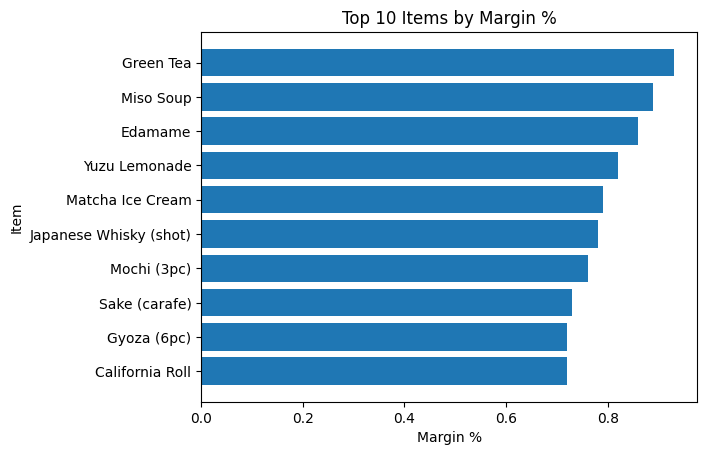

In [79]:
top_items = item_analysis.head(10)

plt.figure()
plt.barh(top_items['item'], top_items['margin_pct'])
plt.title("Top 10 Items by Margin %")
plt.xlabel("Margin %")
plt.ylabel("Item")
plt.gca().invert_yaxis()
plt.show()

In [80]:
category_analysis = final_df.groupby('category').agg({
    'total_revenue': 'sum',
    'total_profit': 'sum',
    'quantity': 'sum',
    'margin_pct': 'mean'
}).reset_index()

category_analysis = category_analysis.sort_values(by='margin_pct', ascending=False)

category_analysis.head(10)

,category,total_revenue,total_profit,quantity,margin_pct
1,drink,663661.5,536972.32,114504,0.841922
6,side,1004774.0,808469.65,200294,0.831290
0,dessert,319763.5,248537.98,51072,0.778661
4,roll,4098946.0,2787746.00,342361,0.681049
2,nigiri,1834585.5,1113591.98,247990,0.607036
3,omakase,583001.0,338140.58,9678,0.580000
5,sashimi,744934.0,424625.45,33021,0.570015


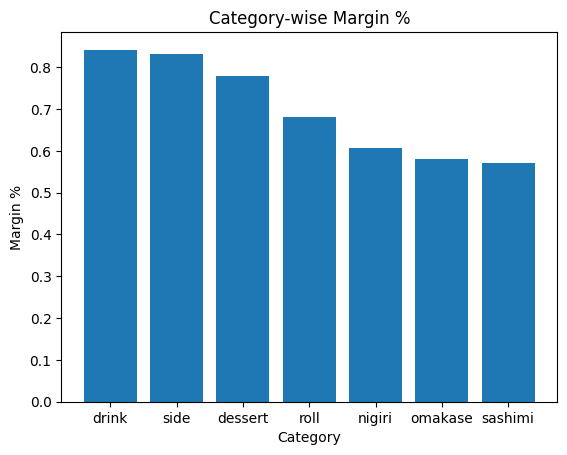

In [81]:
plt.figure()
plt.bar(category_analysis['category'], category_analysis['margin_pct'])
plt.title("Category-wise Margin %")
plt.xlabel("Category")
plt.ylabel("Margin %")
plt.show()

In [82]:
# Add avg price
item_analysis['avg_price'] = item_analysis['total_revenue'] / item_analysis['quantity']

# Define thresholds
margin_mean = item_analysis['margin_pct'].mean()
revenue_mean = item_analysis['total_revenue'].mean()

# Segment items
def classify(row):
    if row['margin_pct'] > margin_mean and row['total_revenue'] > revenue_mean:
        return 'Star'
    elif row['margin_pct'] > margin_mean:
        return 'Cash Cow'
    elif row['total_revenue'] > revenue_mean:
        return 'Volume Driver'
    else:
        return 'Low Performer'

item_analysis['segment'] = item_analysis.apply(classify, axis=1)

In [83]:
item_analysis.head()

,item,total_revenue,total_profit,quantity,margin_pct,avg_price,segment
3,Green Tea,219245.0,203726.96,62666,0.929217,3.498628,Cash Cow
7,Miso Soup,193723.5,172298.61,68418,0.889343,2.831470,Cash Cow
2,Edamame,372962.0,320747.32,81290,0.860000,4.588043,Cash Cow
19,Yuzu Lemonade,108865.5,89269.71,18193,0.820000,5.983922,Cash Cow
6,Matcha Ice Cream,186289.5,147097.74,33109,0.789612,5.626552,Cash Cow


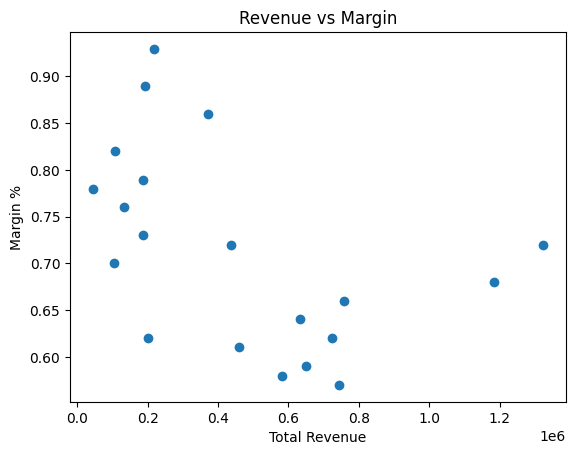

In [84]:
plt.figure()
plt.scatter(item_analysis['total_revenue'], item_analysis['margin_pct'])

plt.title("Revenue vs Margin")
plt.xlabel("Total Revenue")
plt.ylabel("Margin %")
plt.show()

## Inflation / Time Trend Analysis

In [86]:
yearly_analysis = final_df.groupby('year').agg({
    'unit_price': 'mean',
    'total_cogs': 'mean',
    'margin_pct': 'mean'
}).reset_index()

In [87]:
yearly_analysis.describe()

,year,unit_price,total_cogs,margin_pct
count,10.00000,10.000000,10.000000,10.000000
mean,2019.50000,9.369300,4.607372,0.717275
std,3.02765,1.658201,0.660463,0.002159
min,2015.00000,6.972132,3.821327,0.714675
25%,2017.25000,7.913923,3.926561,0.715281
50%,2019.50000,9.895035,4.789731,0.717131
75%,2021.75000,10.798196,5.161168,0.719345
max,2024.00000,11.164151,5.354907,0.720195


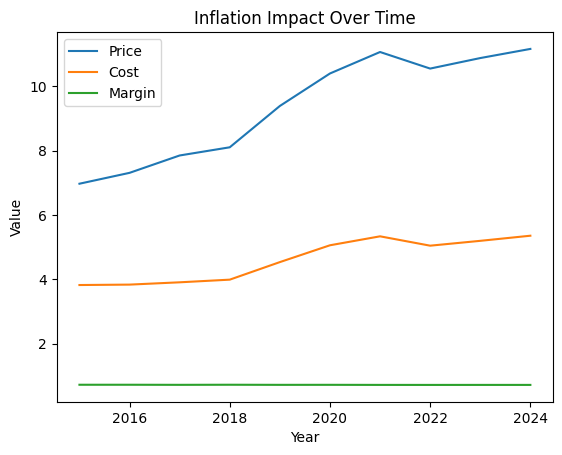

In [88]:
plt.figure()
plt.plot(yearly_analysis['year'], yearly_analysis['unit_price'], label='Price')
plt.plot(yearly_analysis['year'], yearly_analysis['total_cogs'], label='Cost')
plt.plot(yearly_analysis['year'], yearly_analysis['margin_pct'], label='Margin')

plt.title("Inflation Impact Over Time")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

In [89]:
category_trend = final_df.groupby(['year', 'category']).agg({
    'margin_pct': 'mean'
}).reset_index()

In [90]:
print ( category_trend)

    year category  margin_pct
0   2015  dessert    0.790000
1   2015    drink    0.843639
2   2015   nigiri    0.606748
3   2015     roll    0.691144
4   2015  sashimi    0.569823
5   2015     side    0.873315
6   2016  dessert    0.790000
7   2016    drink    0.847772
8   2016   nigiri    0.607169
9   2016     roll    0.691222
10  2016  sashimi    0.570031
11  2016     side    0.828338
12  2017  dessert    0.777386
13  2017    drink    0.849966
14  2017   nigiri    0.607108
15  2017     roll    0.682827
16  2017  sashimi    0.570118
17  2017     side    0.828165
18  2018  dessert    0.777513
19  2018    drink    0.844176
20  2018   nigiri    0.607079
21  2018     roll    0.682749
22  2018  sashimi    0.569837
23  2018     side    0.828897
24  2019  dessert    0.777088
25  2019    drink    0.840525
26  2019   nigiri    0.607040
27  2019  omakase    0.580000
28  2019     roll    0.682777
29  2019  sashimi    0.570138
30  2019     side    0.829632
31  2020  dessert    0.777306
32  2020  

## “Overall margins are stable, but some categories show slight margin compression indicating might be possible localized pricing pressure.”

 # Key Insight:
* Most categories → stable margins 
* Rolls & dessert → slight decline 
* Sashimi → consistently low 

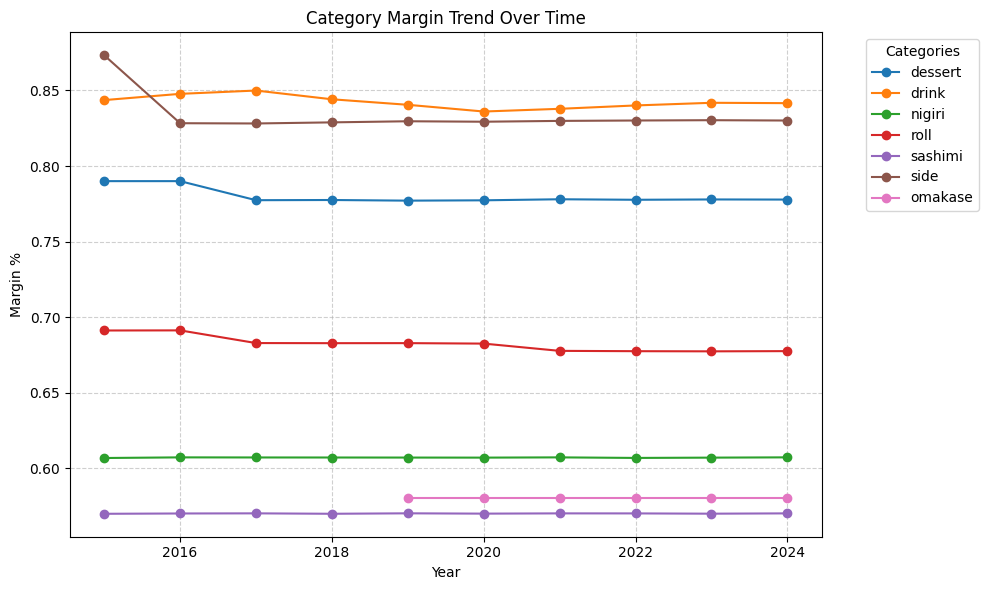

In [93]:
plt.figure(figsize=(10, 6))

for category in category_trend['category'].unique():
    subset = category_trend[category_trend['category'] == category]
    plt.plot(subset['year'], subset['margin_pct'], label=category, marker='o') 

plt.title("Category Margin Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Margin %")


plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.6) #
plt.tight_layout() 
plt.show()

In [94]:
channel_analysis = final_df.groupby('channel').agg({
    'total_revenue': 'sum',
    'total_profit': 'sum',
    'margin_pct': 'mean'
}).reset_index()

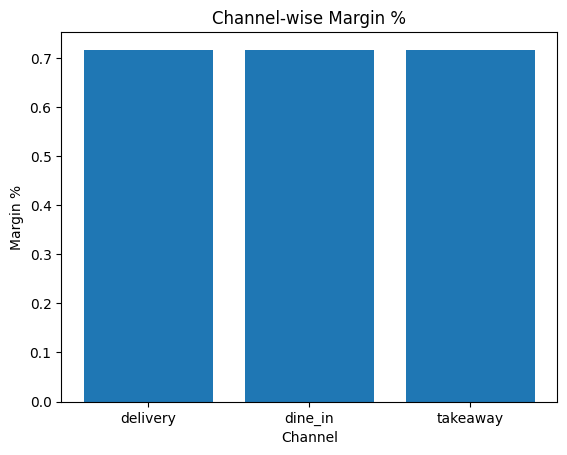

In [95]:
plt.figure()
plt.bar(channel_analysis['channel'], channel_analysis['margin_pct'])
plt.title("Channel-wise Margin %")
plt.xlabel("Channel")
plt.ylabel("Margin %")
plt.show()

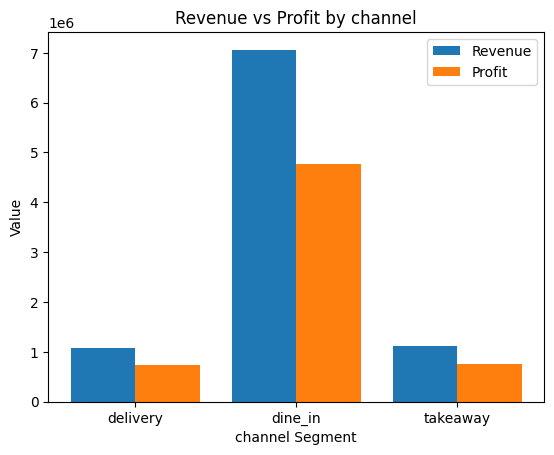

In [183]:
x = np.arange(len(channel_analysis['channel']))

plt.figure()
plt.bar(x - 0.2, channel_analysis['total_revenue'], width=0.4, label='Revenue')
plt.bar(x + 0.2, channel_analysis['total_profit'], width=0.4, label='Profit')

plt.xticks(x, channel_analysis['channel'])
plt.title("Revenue vs Profit by channel")
plt.xlabel("channel Segment")
plt.ylabel("Value")

plt.legend()
plt.show()

In [96]:
channel_analysis[['channel', 'total_revenue', 'total_profit']]

,channel,total_revenue,total_profit
0,delivery,1079904.0,731284.35
1,dine_in,7064163.0,4777471.28
2,takeaway,1105598.5,749328.33


In [97]:
segment_analysis = final_df.groupby('customer_segment').agg({
    'total_revenue': 'sum',
    'total_profit': 'sum',
    'margin_pct': 'mean'
}).reset_index()

## Revenue by Segment (BAR CHART)

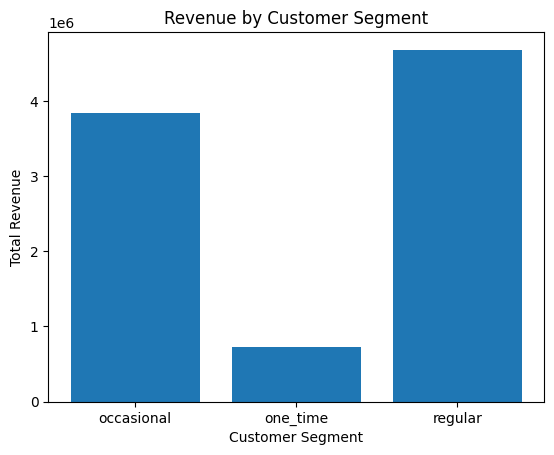

In [99]:
plt.figure()
plt.bar(segment_analysis['customer_segment'], segment_analysis['total_revenue'])

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.show()

## Profit by Segment (BAR CHART)`

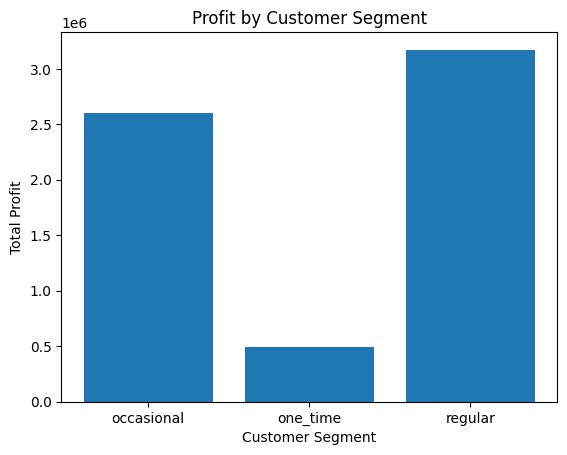

In [101]:
plt.figure()
plt.bar(segment_analysis['customer_segment'], segment_analysis['total_profit'])

plt.title("Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.show()

## Margin % by Segment (BAR CHART)

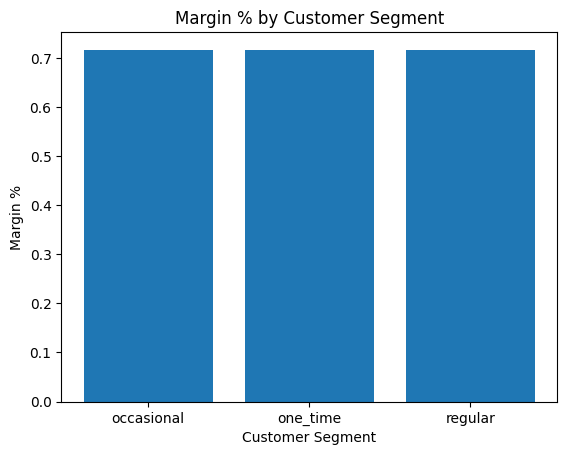

In [103]:
plt.figure()
plt.bar(segment_analysis['customer_segment'], segment_analysis['margin_pct'])

plt.title("Margin % by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Margin %")

plt.show()

## Revenue Share (PIE CHART) 🔥

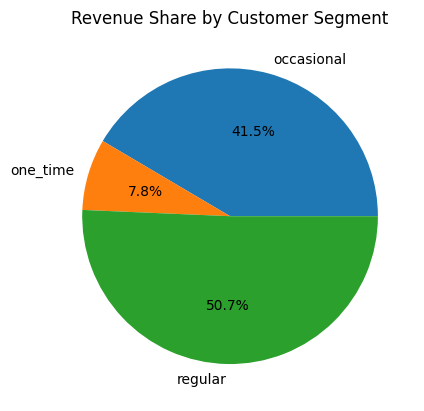

In [105]:
plt.figure()
plt.pie(segment_analysis['total_revenue'],
        labels=segment_analysis['customer_segment'],
        autopct='%1.1f%%')

plt.title("Revenue Share by Customer Segment")

plt.show()

## Combined View (Revenue vs Profit)

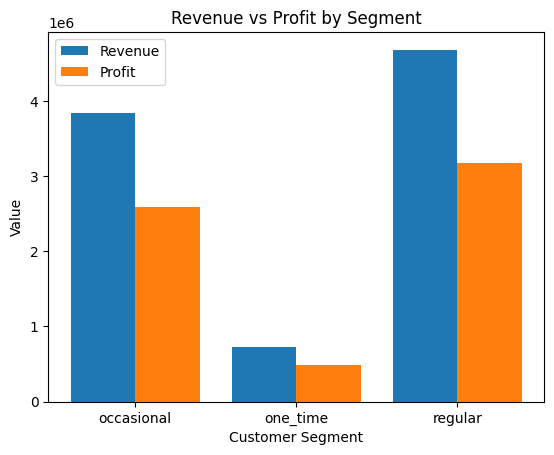

In [107]:
x = np.arange(len(segment_analysis['customer_segment']))

plt.figure()
plt.bar(x - 0.2, segment_analysis['total_revenue'], width=0.4, label='Revenue')
plt.bar(x + 0.2, segment_analysis['total_profit'], width=0.4, label='Profit')

plt.xticks(x, segment_analysis['customer_segment'])
plt.title("Revenue vs Profit by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Value")

plt.legend()
plt.show()

In [108]:
low_margin_high_revenue = item_analysis[
    (item_analysis['margin_pct'] < item_analysis['margin_pct'].mean()) &
    (item_analysis['total_revenue'] > item_analysis['total_revenue'].mean())
]

## Scatter Plot with Quadrants

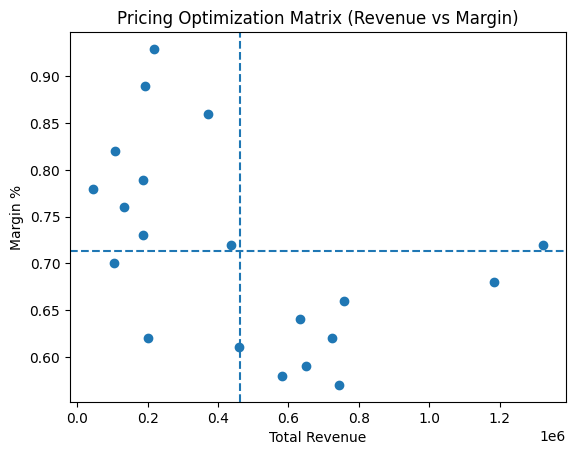

In [110]:
plt.figure()

plt.scatter(item_analysis['total_revenue'], item_analysis['margin_pct'])

# Add mean lines (to create quadrants)
plt.axhline(item_analysis['margin_pct'].mean(), linestyle='--')
plt.axvline(item_analysis['total_revenue'].mean(), linestyle='--')

plt.title("Pricing Optimization Matrix (Revenue vs Margin)")
plt.xlabel("Total Revenue")
plt.ylabel("Margin %")

plt.show()

## Highlight Only Problem Items

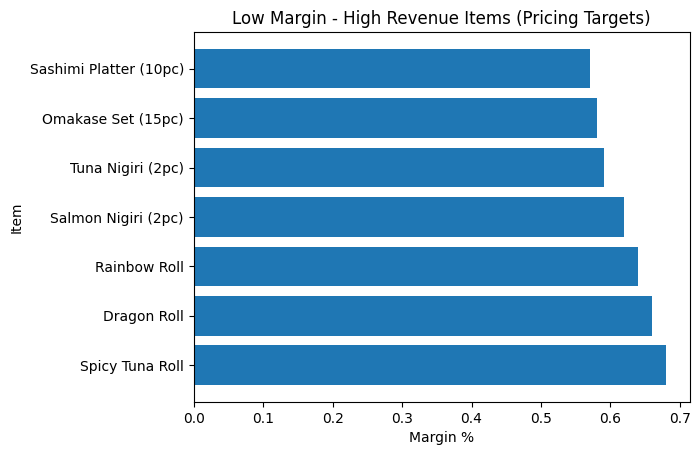

In [112]:
plt.figure()

plt.barh(low_margin_high_revenue['item'],
         low_margin_high_revenue['margin_pct'])

plt.title("Low Margin - High Revenue Items (Pricing Targets)")
plt.xlabel("Margin %")
plt.ylabel("Item")

plt.show()

## Top Revenue vs Margin Comparison

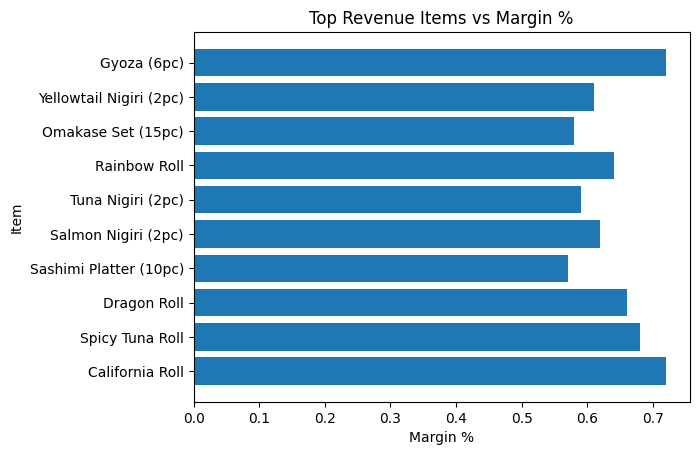

In [114]:
top_revenue_items = item_analysis.sort_values(
    by='total_revenue', ascending=False).head(10)

plt.figure()
plt.barh(top_revenue_items['item'], top_revenue_items['margin_pct'])

plt.title("Top Revenue Items vs Margin %")
plt.xlabel("Margin %")
plt.ylabel("Item")

plt.show()

In [116]:
avg_margin = item_analysis['margin_pct'].mean()
avg_revenue = item_analysis['total_revenue'].mean()

pricing_targets = item_analysis[
    (item_analysis['margin_pct'] < avg_margin) &
    (item_analysis['total_revenue'] > avg_revenue)
]

In [117]:
item_analysis.head()
category_analysis.head()
yearly_analysis.head()
channel_analysis.head()
segment_analysis.head()
pricing_targets

,item,total_revenue,total_profit,quantity,margin_pct,avg_price,segment
15,Spicy Tuna Roll,1183306.0,804648.08,108172,0.680000,10.939115,Volume Driver
1,Dragon Roll,757805.5,500151.63,52001,0.660000,14.572902,Volume Driver
10,Rainbow Roll,632875.0,405040.00,36332,0.640000,17.419217,Volume Driver
12,Salmon Nigiri (2pc),724285.5,449057.01,104982,0.620000,6.899140,Volume Driver
17,Tuna Nigiri (2pc),650506.0,384014.02,86620,0.590326,7.509882,Volume Driver
9,Omakase Set (15pc),583001.0,338140.58,9678,0.580000,60.239822,Volume Driver
14,Sashimi Platter (10pc),744934.0,424625.45,33021,0.570015,22.559402,Volume Driver


In [118]:
final_df.to_csv("final_dataset.csv", index=False)